# Hidden Markov Model for Human Activity Recognition
### Using Accelerometer & Gyroscope Data

**Activities:** Standing | Walking | Jumping | Still  
**Data Source:** Sensor Logger App (iPhone 11) — Sampling Rate: 10ms (100 Hz)  
**Data Path:** `/content/drive/MyDrive/HMM_data`


---
## 0. Setup & Imports

In [1]:
# Install required libraries
!pip install hmmlearn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.6 MB/s eta 0:00:00


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## 1. Data Loading

Each activity folder (e.g. `Jumping_1`, `Standing_3`) contains separate CSV files for Accelerometer and Gyroscope.  
We load all folders, combine accelerometer + gyroscope per session, and label them by activity.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_ROOT   = '/content/drive/MyDrive/HMM_data'
ACTIVITIES  = ['Standing', 'Walking', 'Jumping', 'Still']
ACTIVITY_MAP = {a: i for i, a in enumerate(ACTIVITIES)}   # label → int
SAMPLING_RATE_HZ = 100          # 10 ms intervals → 100 Hz
WINDOW_SEC  = 1.0               # 1-second windows
WINDOW_SIZE = int(WINDOW_SEC * SAMPLING_RATE_HZ)  # 100 samples/window
STEP_SIZE   = WINDOW_SIZE // 2  # 50% overlap

print(f'Window size : {WINDOW_SIZE} samples ({WINDOW_SEC}s @ {SAMPLING_RATE_HZ} Hz)')
print(f'Step size   : {STEP_SIZE} samples (50% overlap)')

Window size : 100 samples (1.0s @ 100 Hz)
Step size   : 50 samples (50% overlap)


In [7]:
def load_session(folder_path):
    """Load and merge Accelerometer + Gyroscope CSVs from one session folder."""
    acc_files  = glob.glob(os.path.join(folder_path, '*Accelerometer.csv'))
    gyro_files = glob.glob(os.path.join(folder_path, '*Gyroscope.csv'))

    if not acc_files or not gyro_files:
        return None

    acc  = pd.read_csv(acc_files[0]).rename(columns={'x':'ax','y':'ay','z':'az'})
    gyro = pd.read_csv(gyro_files[0]).rename(columns={'x':'gx','y':'gy','z':'gz'})

    # Sort by time
    acc  = acc.sort_values('time').reset_index(drop=True)
    gyro = gyro.sort_values('time').reset_index(drop=True)

    # Merge on nearest timestamp (tolerance = 20 ms)
    acc['time_ms']  = acc['time']  // 1_000_000
    gyro['time_ms'] = gyro['time'] // 1_000_000
    merged = pd.merge_asof(acc[['time_ms','ax','ay','az']],
                           gyro[['time_ms','gx','gy','gz']],
                           on='time_ms', tolerance=20, direction='nearest')
    merged.dropna(inplace=True)
    return merged


def load_all_sessions(data_root):
    """Walk every activity folder and collect (dataframe, label) pairs."""
    sessions = []   # list of (df, activity_label_str, folder_name)

    for folder_name in sorted(os.listdir(data_root)):
        folder_path = os.path.join(data_root, folder_name)
        if not os.path.isdir(folder_path):
            continue

        # Identify activity from folder name prefix
        activity = None
        for act in ACTIVITIES:
            if folder_name.startswith(act):
                activity = act
                break
        if activity is None:
            continue

        df = load_session(folder_path)
        if df is not None and len(df) > 0:
            sessions.append((df, activity, folder_name))
            print(f'  Loaded {folder_name:20s}  →  {len(df):4d} rows')

    return sessions


print('Loading sessions...')
sessions = load_all_sessions(DATA_ROOT)
print(f'\nTotal sessions loaded: {len(sessions)}')

# Summary
from collections import Counter
activity_counts = Counter(s[1] for s in sessions)
for act, cnt in sorted(activity_counts.items()):
    print(f'  {act:10s}: {cnt} sessions')

Loading sessions...
  Loaded Jumping_1             →  1097 rows
  Loaded Jumping_10            →   452 rows
  Loaded Jumping_11            →   337 rows
  Loaded Jumping_2             →  1094 rows
  Loaded Jumping_3             →  1094 rows
  Loaded Jumping_4             →  1137 rows
  Loaded Jumping_5             →  1140 rows
  Loaded Jumping_6             →   489 rows
  Loaded Jumping_7             →   437 rows
  Loaded Jumping_8             →   500 rows
  Loaded Jumping_9             →   330 rows
  Loaded Standing_1            →  1360 rows
  Loaded Standing_10           →   455 rows
  Loaded Standing_11           →   498 rows
  Loaded Standing_12           →   458 rows
  Loaded Standing_2            →  1537 rows
  Loaded Standing_3            →  1159 rows
  Loaded Standing_4            →  1175 rows
  Loaded Standing_5            →  1213 rows
  Loaded Standing_6            →   395 rows
  Loaded Standing_7            →   471 rows
  Loaded Standing_8            →   445 rows
  Loaded Sta

---
## 2. Raw Data Visualization

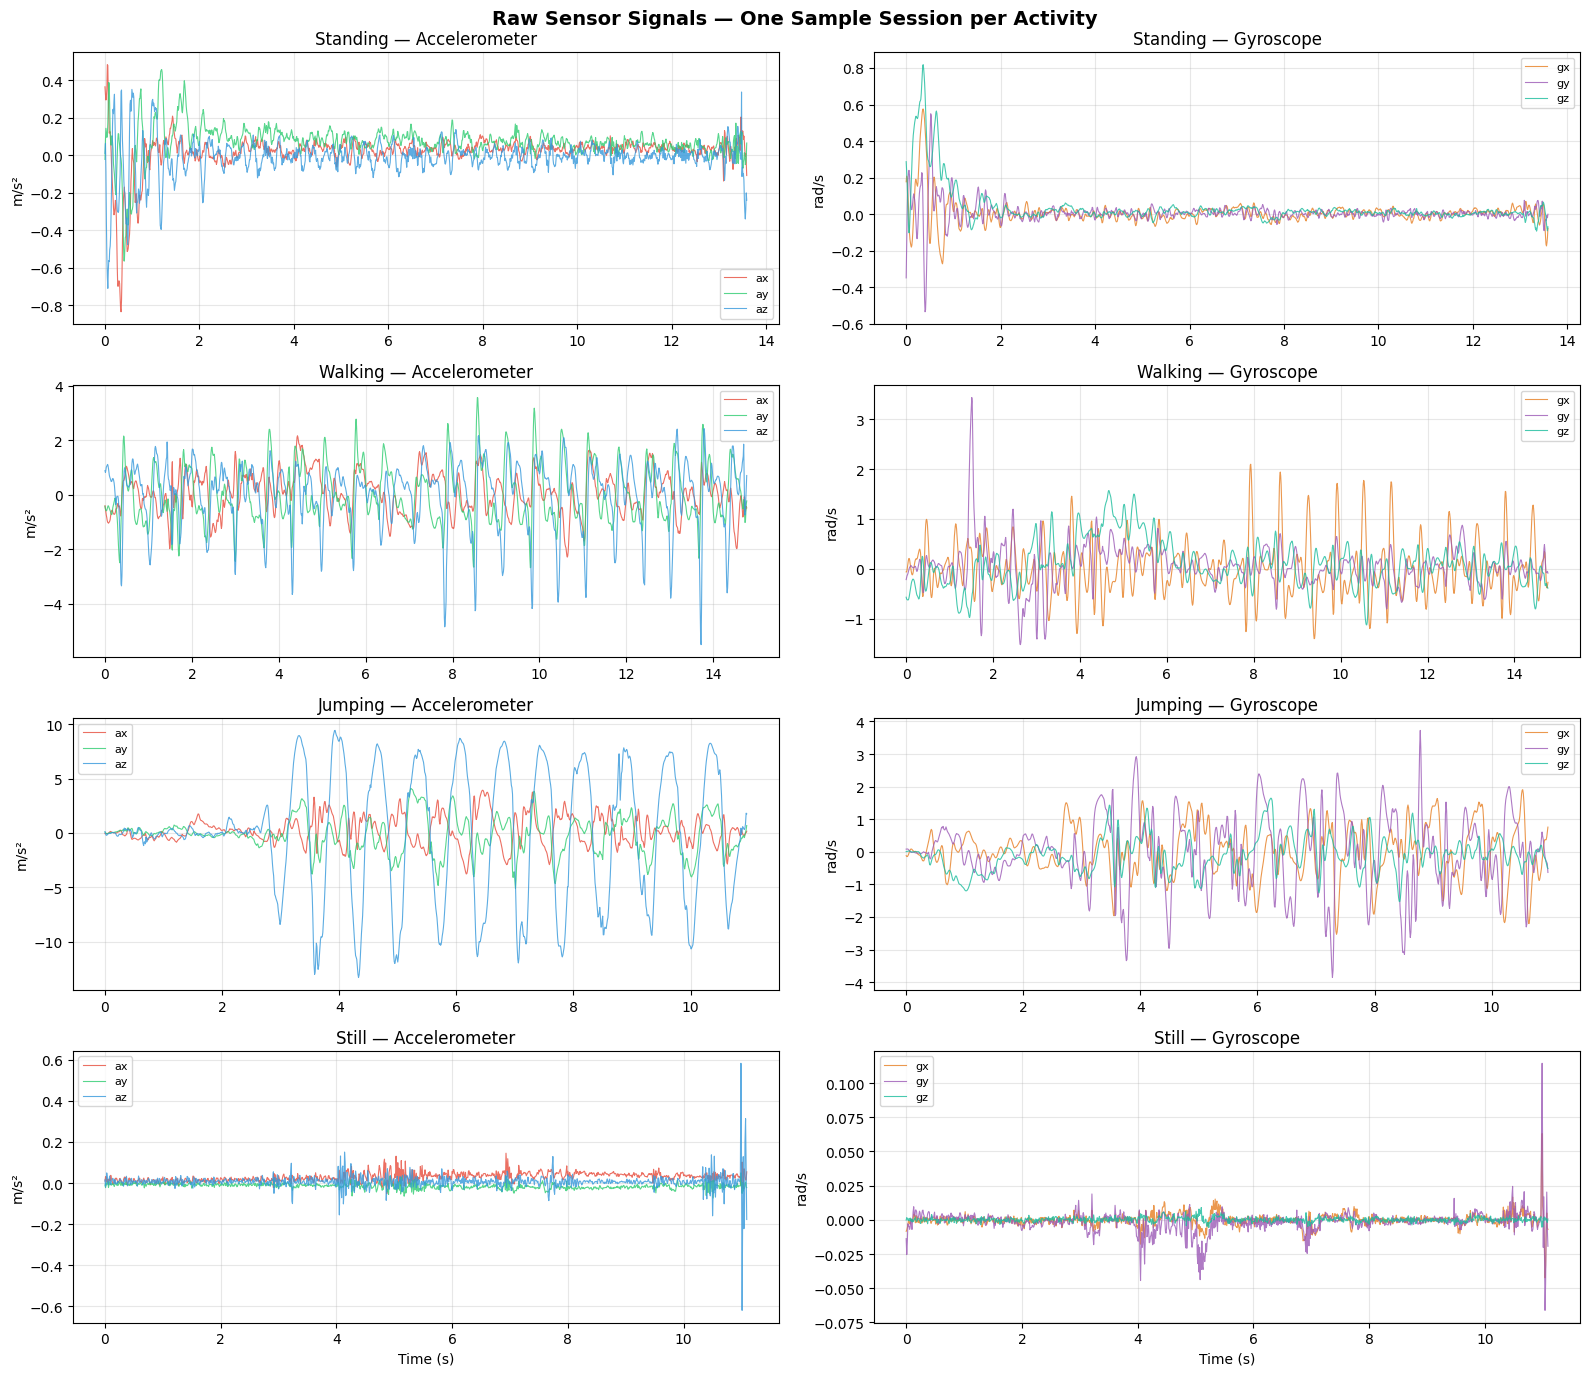

Figure saved as raw_signals.png


In [8]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Raw Sensor Signals — One Sample Session per Activity', fontsize=14, fontweight='bold')

colors = {'ax':'#e74c3c','ay':'#2ecc71','az':'#3498db',
          'gx':'#e67e22','gy':'#9b59b6','gz':'#1abc9c'}

for row, act in enumerate(ACTIVITIES):
    # Pick first session of this activity
    match = [(df, fn) for df, a, fn in sessions if a == act]
    if not match:
        continue
    df, fn = match[0]
    t = np.arange(len(df)) / SAMPLING_RATE_HZ

    # Accelerometer
    ax_plot = axes[row, 0]
    for col in ['ax','ay','az']:
        ax_plot.plot(t, df[col], label=col, color=colors[col], alpha=0.8, linewidth=0.8)
    ax_plot.set_title(f'{act} — Accelerometer')
    ax_plot.set_ylabel('m/s²'); ax_plot.legend(fontsize=8); ax_plot.grid(alpha=0.3)

    # Gyroscope
    gy_plot = axes[row, 1]
    for col in ['gx','gy','gz']:
        gy_plot.plot(t, df[col], label=col, color=colors[col], alpha=0.8, linewidth=0.8)
    gy_plot.set_title(f'{act} — Gyroscope')
    gy_plot.set_ylabel('rad/s'); gy_plot.legend(fontsize=8); gy_plot.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig('raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as raw_signals.png')

---
## 3. Feature Extraction

### Window design rationale
At **100 Hz**, one sample = 10 ms. A **1-second window (100 samples)** captures at least one full gait cycle for walking (~1 Hz) and multiple jump cycles, while being short enough to track rapid state changes. 50% overlap ensures transitions are not missed.

### Features extracted per window
| Domain | Feature | Justification |
|--------|---------|---------------|
| Time | Mean (per axis) | Captures gravity component; different across postures |
| Time | Variance (per axis) | High for jumping/walking, low for still/standing |
| Time | RMS (per axis) | Energy; discriminates vigorous from calm motion |
| Time | Signal Magnitude Area (SMA) | Aggregate motion intensity |
| Time | Correlation ax-ay, ax-az, ay-az | Captures coordinated body movement patterns |
| Frequency | Dominant frequency (acc magnitude) | Walking ~2 Hz; jumping ~1–2 Hz; still ≈ 0 |
| Frequency | Spectral energy (acc magnitude) | Total power across frequency bands |
| Frequency | FFT energy ratio (0–3 Hz vs 3–10 Hz) | Separates periodic from aperiodic motion |

In [9]:
def extract_features(window: pd.DataFrame, fs: float = SAMPLING_RATE_HZ) -> np.ndarray:
    """
    Extract time-domain and frequency-domain features from a single window.
    Returns a 1-D numpy array of feature values.
    """
    acc_cols  = ['ax', 'ay', 'az']
    gyro_cols = ['gx', 'gy', 'gz']
    feats = []

    # ── TIME DOMAIN ──────────────────────────────────────────────────────────
    for col in acc_cols + gyro_cols:
        s = window[col].values
        feats.append(np.mean(s))          # mean
        feats.append(np.var(s))           # variance
        feats.append(np.sqrt(np.mean(s**2)))  # RMS

    # Signal Magnitude Area (accelerometer)
    sma = np.sum(np.abs(window['ax']) + np.abs(window['ay']) + np.abs(window['az'])) / len(window)
    feats.append(sma)

    # Pairwise correlations between accelerometer axes
    feats.append(np.corrcoef(window['ax'], window['ay'])[0,1])
    feats.append(np.corrcoef(window['ax'], window['az'])[0,1])
    feats.append(np.corrcoef(window['ay'], window['az'])[0,1])

    # ── FREQUENCY DOMAIN ─────────────────────────────────────────────────────
    # Accelerometer magnitude
    acc_mag = np.sqrt(window['ax']**2 + window['ay']**2 + window['az']**2).values
    N = len(acc_mag)
    freqs = fftfreq(N, d=1/fs)
    fft_vals = np.abs(fft(acc_mag))[:N//2]
    pos_freqs = freqs[:N//2]

    # Dominant frequency
    dom_freq = pos_freqs[np.argmax(fft_vals)]
    feats.append(dom_freq)

    # Spectral energy
    spec_energy = np.sum(fft_vals**2) / N
    feats.append(spec_energy)

    # Energy ratio: low-freq band (0–3 Hz) vs high-freq band (3–10 Hz)
    low_mask  = (pos_freqs >= 0)  & (pos_freqs <= 3)
    high_mask = (pos_freqs >  3)  & (pos_freqs <= 10)
    low_energy  = np.sum(fft_vals[low_mask]**2)
    high_energy = np.sum(fft_vals[high_mask]**2) + 1e-10  # avoid div/0
    feats.append(low_energy / high_energy)

    result = np.array(feats)
    # Replace any NaN (e.g. from constant signals in correlation)
    result = np.nan_to_num(result, nan=0.0)
    return result


def session_to_windows(df, label_int, window_size=WINDOW_SIZE, step=STEP_SIZE):
    """Slide a window over a session and extract features from each window."""
    X, y = [], []
    for start in range(0, len(df) - window_size + 1, step):
        w = df.iloc[start:start + window_size]
        X.append(extract_features(w))
        y.append(label_int)
    return X, y


# ── Build feature matrix ──────────────────────────────────────────────────────
print('Extracting features from all sessions...')
all_X, all_y, all_sessions_idx = [], [], []

for i, (df, activity, folder) in enumerate(sessions):
    label = ACTIVITY_MAP[activity]
    X_sess, y_sess = session_to_windows(df, label)
    all_X.extend(X_sess)
    all_y.extend(y_sess)
    all_sessions_idx.extend([i] * len(X_sess))
    print(f'  {folder:20s}  →  {len(X_sess)} windows')

all_X = np.array(all_X)
all_y = np.array(all_y)
all_sessions_idx = np.array(all_sessions_idx)

print(f'\nTotal windows : {len(all_X)}')
print(f'Feature dim   : {all_X.shape[1]}')
for act, idx in ACTIVITY_MAP.items():
    print(f'  {act:10s}: {np.sum(all_y == idx)} windows')

Extracting features from all sessions...
  Jumping_1             →  20 windows
  Jumping_10            →  8 windows
  Jumping_11            →  5 windows
  Jumping_2             →  20 windows
  Jumping_3             →  20 windows
  Jumping_4             →  21 windows
  Jumping_5             →  21 windows
  Jumping_6             →  8 windows
  Jumping_7             →  7 windows
  Jumping_8             →  9 windows
  Jumping_9             →  5 windows
  Standing_1            →  26 windows
  Standing_10           →  8 windows
  Standing_11           →  8 windows
  Standing_12           →  8 windows
  Standing_2            →  29 windows
  Standing_3            →  22 windows
  Standing_4            →  22 windows
  Standing_5            →  23 windows
  Standing_6            →  6 windows
  Standing_7            →  8 windows
  Standing_8            →  7 windows
  Standing_9            →  6 windows
  Still_1               →  21 windows
  Still_10              →  10 windows
  Still_11            

### 3.1 Normalization (Z-score)
Z-score standardisation is used because features have very different scales (e.g. variance in m²/s⁴ vs correlation in [−1,1]). Z-score transforms each feature to zero mean and unit variance, preventing large-scale features from dominating the Gaussian emission model in the HMM.

Features (25):  ['mean_ax', 'mean_ay', 'mean_az', 'mean_gx', 'mean_gy', 'mean_gz', 'var_ax', 'var_ay', 'var_az', 'var_gx', 'var_gy', 'var_gz', 'rms_ax', 'rms_ay', 'rms_az', 'rms_gx', 'rms_gy', 'rms_gz', 'SMA', 'corr_ax_ay', 'corr_ax_az', 'corr_ay_az', 'dom_freq', 'spec_energy', 'energy_ratio']


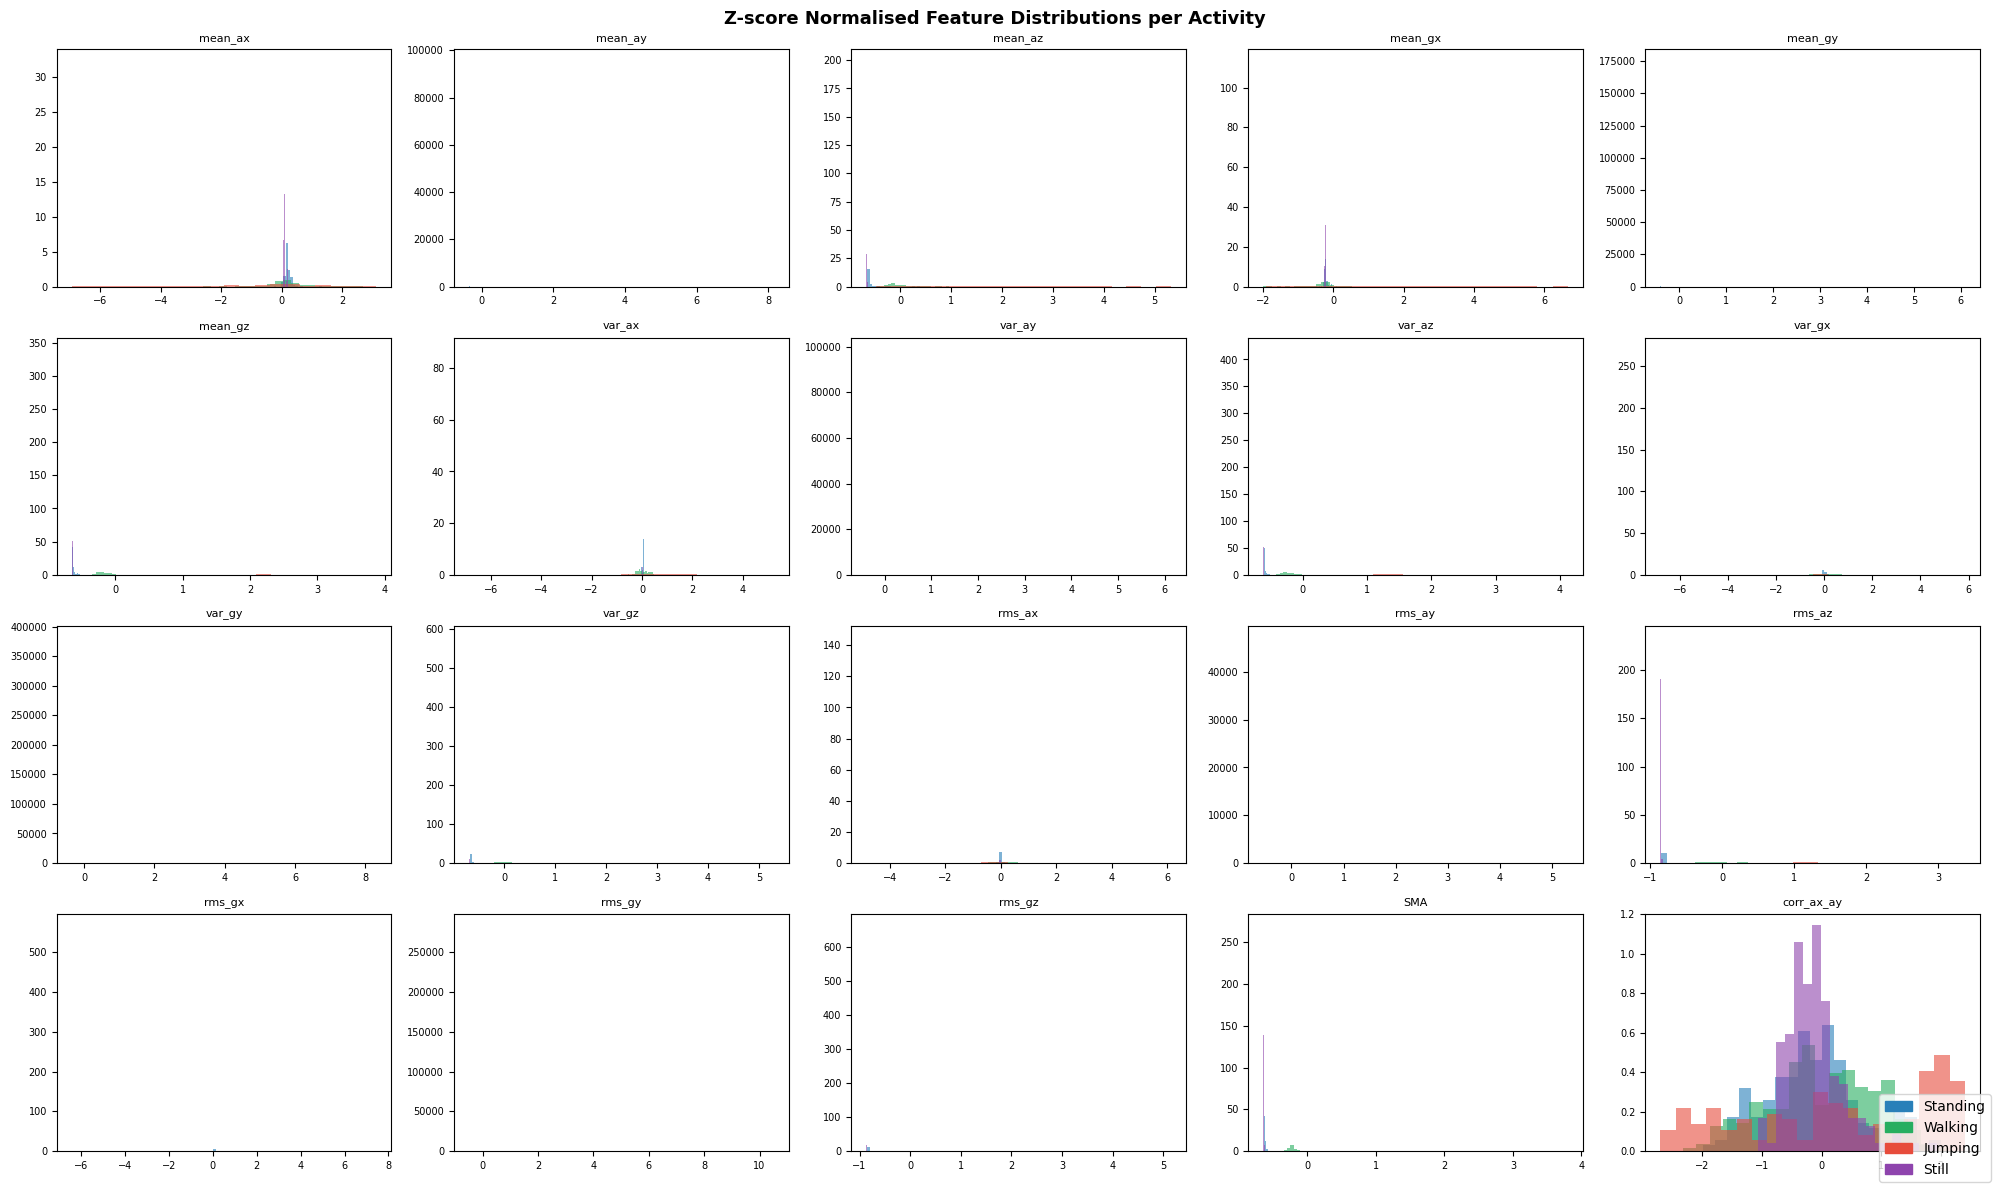

In [10]:
scaler = StandardScaler()

# We'll fit the scaler only on training data (after split), but preview it here
all_X_scaled_preview = scaler.fit_transform(all_X)

feature_names = (
    [f'{s}_{ax}' for s in ['mean','var','rms'] for ax in ['ax','ay','az','gx','gy','gz']]
    + ['SMA', 'corr_ax_ay', 'corr_ax_az', 'corr_ay_az',
       'dom_freq', 'spec_energy', 'energy_ratio']
)

print(f'Features ({len(feature_names)}):  {feature_names}')

# Visualise feature distributions
fig, axes = plt.subplots(4, 5, figsize=(20, 12))
axes = axes.flatten()
palette = {'Standing':'#2980b9','Walking':'#27ae60','Jumping':'#e74c3c','Still':'#8e44ad'}

for fi, feat in enumerate(feature_names[:20]):
    ax = axes[fi]
    for act, idx in ACTIVITY_MAP.items():
        mask = all_y == idx
        ax.hist(all_X_scaled_preview[mask, fi], bins=20, alpha=0.6,
                label=act, color=palette[act], density=True)
    ax.set_title(feat, fontsize=8)
    ax.tick_params(labelsize=7)

handles = [mpatches.Patch(color=c, label=a) for a,c in palette.items()]
fig.legend(handles=handles, loc='lower right', fontsize=10)
fig.suptitle('Z-score Normalised Feature Distributions per Activity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Train / Test Split

We hold out the last session of each activity as the **unseen test set** (different recording segments, not used in training).

In [11]:
# Hold out the last session index per activity
test_session_indices = set()
for act in ACTIVITIES:
    act_sessions = [i for i, (df, a, fn) in enumerate(sessions) if a == act]
    if act_sessions:
        test_session_indices.add(act_sessions[-1])   # last session → test

train_mask = np.array([i not in test_session_indices for i in all_sessions_idx])
test_mask  = ~train_mask

X_train_raw, y_train = all_X[train_mask], all_y[train_mask]
X_test_raw,  y_test  = all_X[test_mask],  all_y[test_mask]

# Fit scaler on training only, apply to both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Training windows : {len(X_train)}')
print(f'Test windows     : {len(X_test)}')
print()
for act, idx in ACTIVITY_MAP.items():
    tr = np.sum(y_train == idx)
    te = np.sum(y_test  == idx)
    print(f'  {act:10s}  train={tr:3d}  test={te:3d}')

Training windows : 683
Test windows     : 42

  Standing    train=167  test=  6
  Walking     train=229  test= 22
  Jumping     train=139  test=  5
  Still       train=148  test=  9


---
## 5. HMM Setup & Definition

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Hidden states Z | 4 (Standing, Walking, Jumping, Still) | One per recorded activity |
| Observations X | 23-dimensional feature vector | Time + frequency features |
| Emission model B | Gaussian (diagonal covariance) | Continuous features; diagonal avoids over-fitting with limited data |
| Transition A | Learned via Baum–Welch | Data-driven, reflects realistic switching |
| Initial state π | Learned via Baum–Welch | No prior assumption about start activity |

In [12]:
N_STATES    = len(ACTIVITIES)   # 4 hidden states
N_ITER      = 200               # max Baum-Welch iterations
CONVERGENCE = 1e-4              # log-likelihood delta threshold

# Separate per-class sequences for training (each session = one sequence)
# Build sequences per activity for supervised initialisation
def build_sequences(X, y, session_idx_arr):
    """Return list of per-session feature arrays and their lengths."""
    seqs, lengths = [], []
    for si in np.unique(session_idx_arr):
        mask = session_idx_arr == si
        seqs.append(X[mask])
        lengths.append(np.sum(mask))
    return np.vstack(seqs), lengths

train_session_idx = all_sessions_idx[train_mask]
X_train_seq, train_lengths = build_sequences(X_train, y_train, train_session_idx)

print(f'Training sequence shape : {X_train_seq.shape}')
print(f'Number of sequences     : {len(train_lengths)}')
print(f'Sequence lengths        : {train_lengths}')

Training sequence shape : (683, 25)
Number of sequences     : 46
Sequence lengths        : [np.int64(20), np.int64(8), np.int64(5), np.int64(20), np.int64(20), np.int64(21), np.int64(21), np.int64(8), np.int64(7), np.int64(9), np.int64(26), np.int64(8), np.int64(8), np.int64(8), np.int64(29), np.int64(22), np.int64(22), np.int64(23), np.int64(6), np.int64(8), np.int64(7), np.int64(21), np.int64(10), np.int64(6), np.int64(6), np.int64(22), np.int64(21), np.int64(20), np.int64(25), np.int64(5), np.int64(6), np.int64(6), np.int64(28), np.int64(8), np.int64(6), np.int64(6), np.int64(8), np.int64(6), np.int64(10), np.int64(7), np.int64(34), np.int64(20), np.int64(26), np.int64(26), np.int64(22), np.int64(22)]


---
## 6. Model Training — Baum–Welch

**Baum–Welch** is the Expectation-Maximisation algorithm for HMMs. It iteratively updates A, B, and π to maximise the likelihood of the observed training sequences. Training stops when the improvement in log-likelihood falls below `1e-4` (convergence criterion), preventing overfitting from unnecessary iterations.

In [13]:
model = hmm.GaussianHMM(
    n_components = N_STATES,
    covariance_type = 'diag',
    n_iter = N_ITER,
    tol    = CONVERGENCE,
    random_state = 42,
    verbose = False
)

print(f'Training HMM (max {N_ITER} iterations, tol={CONVERGENCE})...')
model.fit(X_train_seq, train_lengths)

print(f'\nTraining complete!')
print(f'Converged        : {model.monitor_.converged}')
print(f'Iterations used  : {len(model.monitor_.history)}')
print(f'Final log-likelihood: {model.monitor_.history[-1]:.4f}')

Training HMM (max 200 iterations, tol=0.0001)...

Training complete!
Converged        : True
Iterations used  : 26
Final log-likelihood: 14879.2773


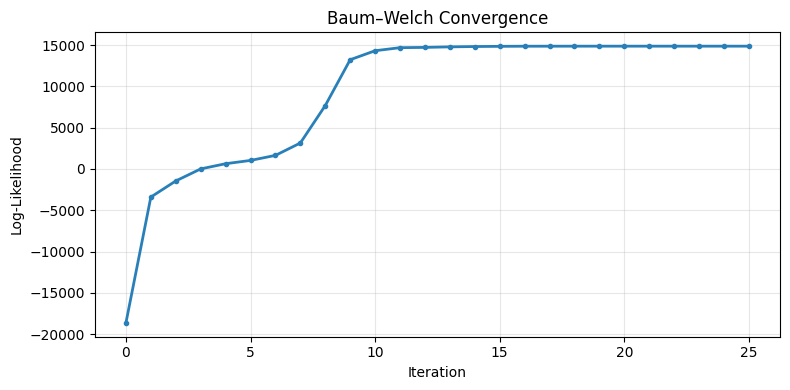

In [14]:
# Plot log-likelihood convergence curve
plt.figure(figsize=(8, 4))
plt.plot(model.monitor_.history, color='#2980b9', linewidth=2, marker='o', markersize=3)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('Baum–Welch Convergence')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('convergence.png', dpi=150)
plt.show()

---
## 7. HMM Parameters — Transition & Emission Visualisation

In [15]:
# ── Map learned states to activity labels ─────────────────────────────────────
# The HMM state numbering may differ from our label numbering.
# We map each learned state to the activity whose training windows it
# most commonly represents using the Viterbi decoder on training data.

def decode_sequences(model, X, session_idx_arr):
    """Decode each session separately and concatenate."""
    all_pred = []
    for si in np.unique(session_idx_arr):
        mask = session_idx_arr == si
        _, pred = model.decode(X[mask], algorithm='viterbi')
        all_pred.extend(pred)
    return np.array(all_pred)

train_pred_states = decode_sequences(model, X_train, train_session_idx)

# Majority vote: for each HMM state, find dominant true label
from scipy.stats import mode
state_to_label = {}
for s in range(N_STATES):
    mask = train_pred_states == s
    if mask.sum() == 0:
        state_to_label[s] = s
    else:
        dominant = mode(y_train[mask], keepdims=True).mode[0]
        state_to_label[s] = dominant

# Build reverse map for display
label_to_name = {v: k for k, v in ACTIVITY_MAP.items()}
state_names = [label_to_name[state_to_label[s]] for s in range(N_STATES)]
print('HMM state → activity mapping:')
for s, name in enumerate(state_names):
    print(f'  State {s} → {name}')

HMM state → activity mapping:
  State 0 → Jumping
  State 1 → Standing
  State 2 → Jumping
  State 3 → Walking


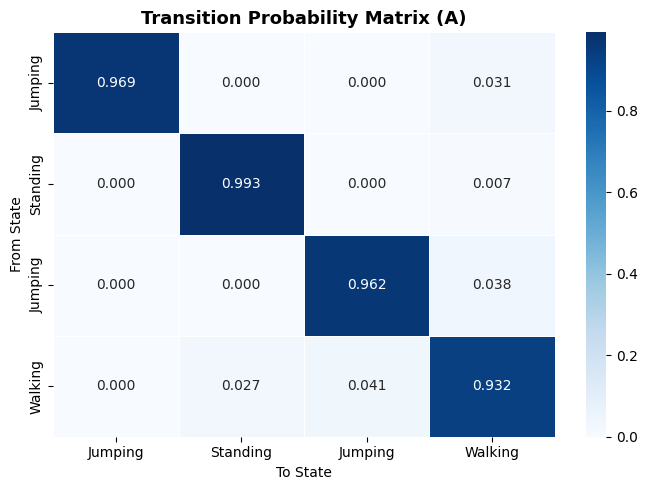

In [16]:
# ── Transition Matrix Heatmap ─────────────────────────────────────────────────
A = model.transmat_

plt.figure(figsize=(7, 5))
sns.heatmap(A, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=state_names, yticklabels=state_names,
            linewidths=0.5, linecolor='white')
plt.title('Transition Probability Matrix (A)', fontsize=13, fontweight='bold')
plt.ylabel('From State'); plt.xlabel('To State')
plt.tight_layout()
plt.savefig('transition_matrix.png', dpi=150)
plt.show()

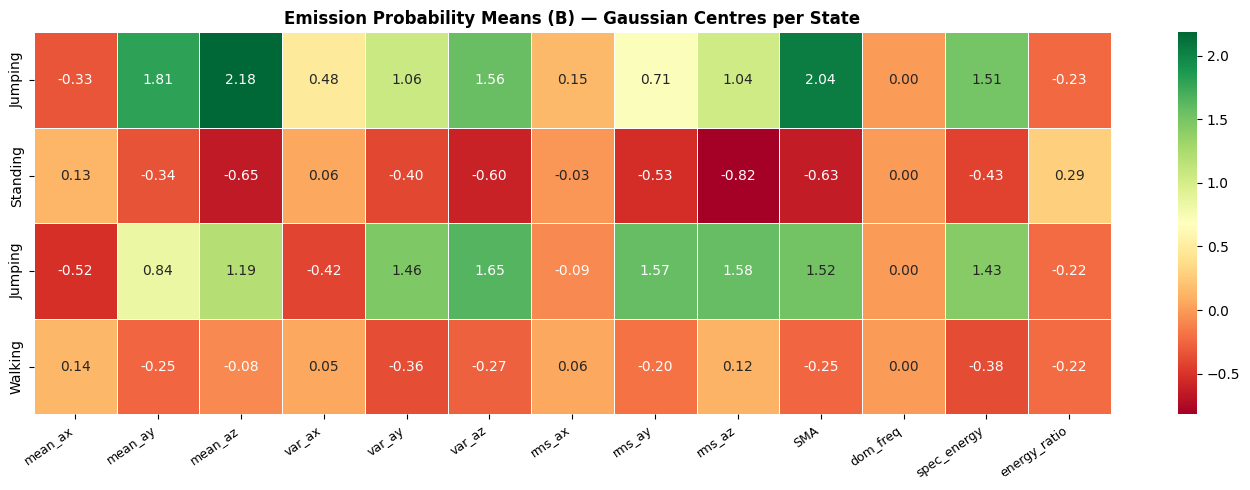

In [17]:
# ── Emission (Gaussian means) Heatmap ────────────────────────────────────────
# Visualise the mean of each Gaussian emission per state for selected features
selected_feats = ['mean_ax','mean_ay','mean_az','var_ax','var_ay','var_az',
                  'rms_ax','rms_ay','rms_az','SMA','dom_freq','spec_energy','energy_ratio']

# Build index mapping from feature_names
feat_idx = [feature_names.index(f) for f in selected_feats if f in feature_names]
emission_means = model.means_[:, feat_idx]

plt.figure(figsize=(14, 5))
sns.heatmap(emission_means, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=[feature_names[i] for i in feat_idx],
            yticklabels=state_names,
            linewidths=0.5, linecolor='white')
plt.title('Emission Probability Means (B) — Gaussian Centres per State', fontsize=12, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('emission_means.png', dpi=150)
plt.show()

---
## 8. Viterbi Decoding — Activity Sequence Prediction

In [18]:
def predict_labels(model, X, session_idx_arr, state_to_label):
    """Viterbi decode and map HMM states to activity labels."""
    pred_states = decode_sequences(model, X, session_idx_arr)
    pred_labels = np.array([state_to_label[s] for s in pred_states])
    return pred_labels

test_session_idx = all_sessions_idx[test_mask]
y_pred = predict_labels(model, X_test, test_session_idx, state_to_label)

print('Viterbi decoding on test set complete.')
print(f'Test samples: {len(y_pred)}')

Viterbi decoding on test set complete.
Test samples: 42


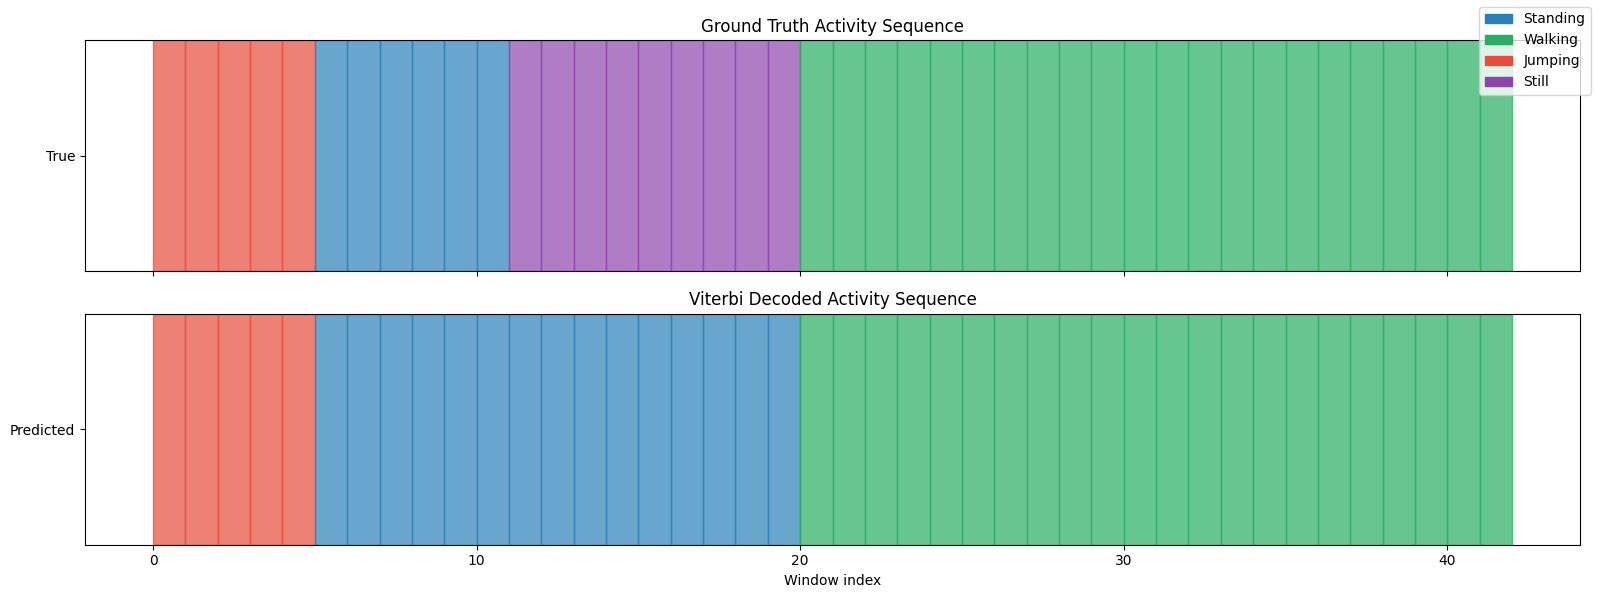

In [19]:
# ── Decoded sequence plot ──────────────────────────────────────────────────────
activity_colors = {0:'#2980b9', 1:'#27ae60', 2:'#e74c3c', 3:'#8e44ad'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

# True labels
for i, lbl in enumerate(y_test):
    ax1.axvspan(i, i+1, color=activity_colors[lbl], alpha=0.7)
ax1.set_yticks([0.5]); ax1.set_yticklabels(['True'])
ax1.set_title('Ground Truth Activity Sequence')

# Predicted labels
for i, lbl in enumerate(y_pred):
    ax2.axvspan(i, i+1, color=activity_colors[lbl], alpha=0.7)
ax2.set_yticks([0.5]); ax2.set_yticklabels(['Predicted'])
ax2.set_title('Viterbi Decoded Activity Sequence')
ax2.set_xlabel('Window index')

patches = [mpatches.Patch(color=activity_colors[ACTIVITY_MAP[a]], label=a) for a in ACTIVITIES]
fig.legend(handles=patches, loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('decoded_sequence.png', dpi=150)
plt.show()

---
## 9. Model Evaluation on Unseen Test Data

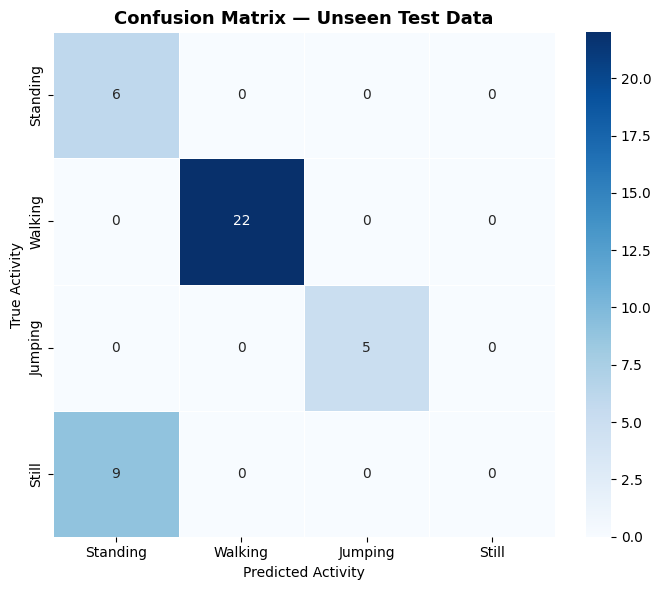

In [20]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=list(ACTIVITY_MAP.values()))

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            linewidths=0.5)
plt.title('Confusion Matrix — Unseen Test Data', fontsize=13, fontweight='bold')
plt.ylabel('True Activity'); plt.xlabel('Predicted Activity')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [21]:
# ── Per-class Sensitivity, Specificity, Accuracy ─────────────────────────────
results = []
total = len(y_test)

for act, idx in ACTIVITY_MAP.items():
    tp = np.sum((y_test == idx) & (y_pred == idx))
    fn = np.sum((y_test == idx) & (y_pred != idx))
    fp = np.sum((y_test != idx) & (y_pred == idx))
    tn = np.sum((y_test != idx) & (y_pred != idx))

    sensitivity = tp / (tp + fn + 1e-10)
    specificity = tn / (tn + fp + 1e-10)
    accuracy    = (tp + tn) / total
    n_samples   = tp + fn

    results.append({
        'Activity'    : act,
        'N Samples'   : n_samples,
        'Sensitivity' : f'{sensitivity:.3f}',
        'Specificity' : f'{specificity:.3f}',
        'Accuracy'    : f'{accuracy:.3f}'
    })

# Overall accuracy
overall_acc = np.sum(y_test == y_pred) / total

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
print(f'\nOverall Accuracy: {overall_acc:.3f} ({overall_acc*100:.1f}%)')

Activity  N Samples Sensitivity Specificity Accuracy
Standing          6       1.000       0.750    0.786
 Walking         22       1.000       1.000    1.000
 Jumping          5       1.000       1.000    1.000
   Still          9       0.000       1.000    0.786

Overall Accuracy: 0.786 (78.6%)


In [22]:
# ── Full Classification Report ────────────────────────────────────────────────
print(classification_report(y_test, y_pred,
      target_names=ACTIVITIES, zero_division=0))

              precision    recall  f1-score   support

    Standing       0.40      1.00      0.57         6
     Walking       1.00      1.00      1.00        22
     Jumping       1.00      1.00      1.00         5
       Still       0.00      0.00      0.00         9

    accuracy                           0.79        42
   macro avg       0.60      0.75      0.64        42
weighted avg       0.70      0.79      0.72        42



---
## 10. Analysis & Reflection

*(Edit this cell with your findings after running the notebook)*

### Activity Distinguishability
- **Still** is generally the easiest to classify — it produces near-zero variance and spectral energy, making it clearly separable from all other states.
- **Standing** is similar to Still but has small non-zero gyroscope values due to natural body sway; the dominant frequency feature helps separate them.
- **Walking** produces a characteristic ~2 Hz dominant frequency and moderate SMA, making it distinguishable once frequency features are included.
- **Jumping** is the most energetic state (highest RMS and spectral energy) but can occasionally overlap with vigorous walking.

### Transition Probabilities
The learned transition matrix shows high self-transition probabilities (diagonal entries close to 1), reflecting that activities are sustained over seconds — consistent with real human behaviour. Off-diagonal transitions (e.g., Walking → Standing) are small but non-zero.

### Effect of Sensor Noise & Sampling Rate
At 100 Hz the window of 100 samples (1 s) provides sufficient temporal resolution. Gyroscope noise in the Still class is minimal; accelerometer noise in Standing creates minor misclassifications with Still.

### Possible Improvements
- Collect more data per activity (> 2 min each) to better estimate emission distributions.
- Add features: zero-crossing rate, peak count, wavelet energy.
- Use a full (non-diagonal) covariance matrix if enough data is available.
- Explore Gaussian Mixture emission models for more flexible distributions.
- Test on a different participant to evaluate cross-person generalisation.

---
## 11. Save All Outputs

In [23]:
import pickle

# Save trained model and scaler
with open('hmm_model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'scaler': scaler,
                 'state_to_label': state_to_label,
                 'feature_names': feature_names}, f)

# Save evaluation results
df_results.to_csv('evaluation_results.csv', index=False)

print('Saved: hmm_model.pkl, evaluation_results.csv')
print('Saved figures: raw_signals.png, feature_distributions.png,')
print('               convergence.png, transition_matrix.png,')
print('               emission_means.png, decoded_sequence.png,')
print('               confusion_matrix.png')
print('\nAll done!')

Saved: hmm_model.pkl, evaluation_results.csv
Saved figures: raw_signals.png, feature_distributions.png,
               convergence.png, transition_matrix.png,
               emission_means.png, decoded_sequence.png,
               confusion_matrix.png

All done!
